# Regular Expressions (regex) - Part 2

### We'll now connect ```regex``` to ```Python```.

**Pages we need:**

- Live Testing: https://regex101.com/
- Sandeep's <a href="https://docs.google.com/spreadsheets/d/1A39lM4SiGZbzZPxrjEXkR05aksAewudccWmojoIU0Gk/edit?usp=sharing">REGEX Tip sheet</a>
- Download <a href="https://drive.google.com/file/d/1thZ7xDTb0IXiauaSvxMskDL_BAFjM_fi/view?usp=sharing">this notebook demo text</a>
- Download these <a href="https://drive.google.com/file/d/1nZ6GMwQKuQEQ2zKftkod4oHh-RqxfwXB/view?usp=sharing">confesssion judgment excerpts</a>




## ```Regex``` Packages

- ``re`` is the oldest and most widely used library. It's showing its age!
- ```regex``` is a newer, fresher library with major advantages over ```re``` as you get more advanced.

In [3]:
pip install "numpy<2"

DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.12/site-packages/dlib-20.0.99-py3.12-macosx-11.1-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
Note: you may need to restart the kernel to use updated packages.


In [75]:
## import libraries
import pandas as pd
import regex as re

In [77]:
## Run this cell
some_text = "The dog barked at the other dog, cat and kitten."

### 1. Simple Python literal search

In [79]:
## is dog in my text
"dog" in some_text

True

In [81]:
## is kitten in my text
"kitten" in some_text

True

In [9]:
## is bird in my text


### 1. ```regex``` pattern compilation

To use a ```regex``` pattern efficiently, we first need to ```compile``` it.

This basically means we are taking a ```regex``` pattern, turning it into something that Python can easily understand – a ```regex Python object```.

You don't have to compile a pattern. The problem if you don't is that each time Python encounters that pattern, it has to process it again. Imagine a ```for loop``` iterating through thousands of documents and compiling the same thing over and over again. Highly inefficient!

And it's easy to compile a pattern.

```regex.compile(some_pattern)``` or ```re.compile(some_pattern)```

In [83]:
## We want to find all the words 'dog' using a pattern
dog_pat = re.compile("d\wg")

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/var/folders/7k/dkrw1dkn70xb44njcjrldx2w0000gn/T/ipykernel_11090/3825931926.py:2: SyntaxWarning: invalid escape sequence '\w'
  dog_pat = re.compile("d\wg")


In [12]:
## set pattern


In [13]:
## type
## we now have a compiled pattern object


### 2. ```search```

- like ```find()``` in BeautifulSoup, ```search()``` returns ONLY the first instance of text found by a pattern.
- It also tells you where the pattern was found.
- Knowing that an instance of a pattern match exists can be used to our advantage (more on this later).

#### ```a_result = pattern_variable.search(some_string)```

In [15]:
some_text

'The dog barked at the other dog, cat and kitten.'

In [85]:
## search for pattern
dog_pat.search(some_text)

<regex.Match object; span=(4, 7), match='dog'>

In [87]:
## run this
other_text = "The military vet who loves her dog was able to overcome her PTSD with the help of a service dog."

In [89]:
## what type of object did (dog_pat.search(some_text) return  ?
type(dog_pat.search(some_text))

_regex.Match

### 3. Returning the match objects

We usually want to do more than simply know that a pattern exists or return its first instance. Ideally, we want to capture it and place it in a spreadsheet.

#### The ```.group()``` method returns the matched pattern as text




In [91]:
## run dog pattern and save in vet_dog
vet_dog = dog_pat.search(other_text)
vet_dog

<regex.Match object; span=(31, 34), match='dog'>

In [93]:
## pull out the matched pattern itself
vet_dog.group()

'dog'

In [95]:
## type 
type(vet_dog.group())

str

## Read our downloaded <a href="https://drive.google.com/file/d/1thZ7xDTb0IXiauaSvxMskDL_BAFjM_fi/view?usp=sharing"> notebook demo text</a>

In [97]:
## read the demo text
with open("regex-notebook-demo.txt", "r") as text_object:
    demo_text = text_object.read()

In [99]:
## call demo text
demo_text

"12534 127 ab aba abba sandeepj@bloomberg.net abbba, abbbbba, (518) 469-4581 abcde.The dog is a not a hog. ABA ABBA ABBBA.\n\nFlorence smith\nJohn Smith\nCarol Brown Tel. 212-452-5728\n\n\nAb_CD123  123456 and 12456\ttor 12531245134562. 123867584789. $40.44 or $3 or $52,583.08 or $610,235.11\nTel. (917) 492-8601\n\nThe cat sat down and called 514-957-3453 while the other caaaaaat purred. This cat is in California while this caaaat is in Iraq, but none are in ct. My dog prefers cat food to dog food but hates fish food.My food tastes yummy!\nPeter Trapp Jon Smythe Luca Smith John Smythe\nMaggie Veach Tel. 718 601 7567\n\nAB_cd \t<+>-.,!@# $%^&*();\\/|_^@1# (917) 488-5410\n\n*!dsar2d1\n\nI told him to search Jon Smith\nKatie Pine\nJohn Smth\n\nTELEPHONE NUMBERS\nTel. 718-392-4793\nTel. (646) 469-3211\nTel. 917.425.2796\n\nNUMBERS\n1\n12\n123\n123,456\n123,456,789\n123,456,789.01\n\nEMAILS\nsandeep.junnarkar@journalism.cuny.edu\nsandeepj@gmail.com\nsjunnarkar@bloomberg.net\nsandeep.junnark

In [101]:
## print variable
print(demo_text)

12534 127 ab aba abba sandeepj@bloomberg.net abbba, abbbbba, (518) 469-4581 abcde.The dog is a not a hog. ABA ABBA ABBBA.

Florence smith
John Smith
Carol Brown Tel. 212-452-5728


Ab_CD123  123456 and 12456	tor 12531245134562. 123867584789. $40.44 or $3 or $52,583.08 or $610,235.11
Tel. (917) 492-8601

The cat sat down and called 514-957-3453 while the other caaaaaat purred. This cat is in California while this caaaat is in Iraq, but none are in ct. My dog prefers cat food to dog food but hates fish food.My food tastes yummy!
Peter Trapp Jon Smythe Luca Smith John Smythe
Maggie Veach Tel. 718 601 7567

AB_cd 	<+>-.,!@# $%^&*();\/|_^@1# (917) 488-5410

*!dsar2d1

I told him to search Jon Smith
Katie Pine
John Smth

TELEPHONE NUMBERS
Tel. 718-392-4793
Tel. (646) 469-3211
Tel. 917.425.2796

NUMBERS
1
12
123
123,456
123,456,789
123,456,789.01

EMAILS
sandeep.junnarkar@journalism.cuny.edu
sandeepj@gmail.com
sjunnarkar@bloomberg.net
sandeep.junnarkar@news.co.uk


POLICE
Det. Frank Castille


### 4. ```findall``` finds every item that matches a pattern

```pattern.findall(text)```

In [103]:
## use findall to find all matching instances of grouped letters, numbers and the underscore
pat = re.compile("\w+")
pat.findall(demo_text)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/var/folders/7k/dkrw1dkn70xb44njcjrldx2w0000gn/T/ipykernel_11090/3602303914.py:2: SyntaxWarning: invalid escape sequence '\w'
  pat = re.compile("\w+")


['12534',
 '127',
 'ab',
 'aba',
 'abba',
 'sandeepj',
 'bloomberg',
 'net',
 'abbba',
 'abbbbba',
 '518',
 '469',
 '4581',
 'abcde',
 'The',
 'dog',
 'is',
 'a',
 'not',
 'a',
 'hog',
 'ABA',
 'ABBA',
 'ABBBA',
 'Florence',
 'smith',
 'John',
 'Smith',
 'Carol',
 'Brown',
 'Tel',
 '212',
 '452',
 '5728',
 'Ab_CD123',
 '123456',
 'and',
 '12456',
 'tor',
 '12531245134562',
 '123867584789',
 '40',
 '44',
 'or',
 '3',
 'or',
 '52',
 '583',
 '08',
 'or',
 '610',
 '235',
 '11',
 'Tel',
 '917',
 '492',
 '8601',
 'The',
 'cat',
 'sat',
 'down',
 'and',
 'called',
 '514',
 '957',
 '3453',
 'while',
 'the',
 'other',
 'caaaaaat',
 'purred',
 'This',
 'cat',
 'is',
 'in',
 'California',
 'while',
 'this',
 'caaaat',
 'is',
 'in',
 'Iraq',
 'but',
 'none',
 'are',
 'in',
 'ct',
 'My',
 'dog',
 'prefers',
 'cat',
 'food',
 'to',
 'dog',
 'food',
 'but',
 'hates',
 'fish',
 'food',
 'My',
 'food',
 'tastes',
 'yummy',
 'Peter',
 'Trapp',
 'Jon',
 'Smythe',
 'Luca',
 'Smith',
 'John',
 'Smythe',
 '

In [105]:
## what object is it?
type(pat.findall(demo_text))

list

In [107]:
## create pattern to find any "a" followed by 1 or 2 "b"
pat2 = re.compile("ab{1,2}")

In [109]:
## FIND pat1
pat2.findall(demo_text)

['ab', 'ab', 'abb', 'abb', 'abb', 'ab', 'ab', 'ab', 'abb']

In [111]:
## call our pat2 to see someting interesting- flags
pat2

regex.Regex('ab{1,2}', flags=regex.V0)

### 5. Flags

Regex flags are optional modifiers that alter the behavior of regular expressions, like making it case-insensitive.

- ```re.IGNORECASE``` or ```re.I``` for ignore case

```re.compile(some_pattern, re.I)```


In [115]:
## find any "a" followed by 1 or 2 "b" ignore case
pat3= re.compile("ab{1,2}", re.I)

In [117]:
## find all matches for pat2
pat3.findall(demo_text)

['ab',
 'ab',
 'abb',
 'abb',
 'abb',
 'ab',
 'AB',
 'ABB',
 'ABB',
 'Ab',
 'AB',
 'ab',
 'ab',
 'AB',
 'abb']

In [119]:
## find "dog" ignore case - full word
pat4 = re.compile("dog", re.I)
pat4.findall(demo_text)

['dog', 'dog', 'dog', 'Dog', 'dog', 'DOG', 'dog']

In [121]:
## find "dog" ignore case - abbreviation
re.compile("dog").findall(demo_text)

['dog', 'dog', 'dog', 'dog', 'dog']

In [38]:
## without ignore case


In [39]:
## match pat4a


## Python Interpreter and Regex conflict with ```\```

In [41]:
## run this ----- skipped this part in class-- just use the raw string option
pet = "dog\ cat"


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/var/folders/7k/dkrw1dkn70xb44njcjrldx2w0000gn/T/ipykernel_11090/3836076532.py:2: SyntaxWarning: invalid escape sequence '\ '
  pet = "dog\ cat"


In [42]:
## call pet


In [43]:
## print  pet


In [44]:
## write regex to find word with 3 characters


In [45]:
### write regex to find word with 3 characters followed by a slash
## we use a slash to escape to say the second slash is an actual slashl
## this will break


### This is confusing but here's just happened:

```re.search("\w{3}\\", pet)```

1. The Python interpreter sees the slash after the } and takes it as an escape character and removes it.
2. The code is then passed on to the Regex, which then sees a single slash which stands for an escape character instead of the slash in the string.
3. Everthing breaks.



### 5. ```r``` Raw String option

**Just add the ```raw string``` option to counteract the Python conflict```

Add an ```r``` before your Regex string to convert it to a raw string.

```re.search(r"\\", pet)```

In [48]:
## raw string works.


In [49]:
## print the target group 


In [50]:
## print it

### When to use raw string ```r```

#### Two cases
1. When you need to escape the ```\``` to actually find a slash.
2. When you need to use ```\b``` word boundary.

But generally just always use ```raw string```

# Put Regex to work

### Multilines Regex

In [54]:
## text string for demo
string = '''line 1 with more to follow.

this is line 2

LINE 3 has more...

Text before line 4
'''

In [55]:
## print string
print(string)

line 1 with more to follow.

this is line 2

LINE 3 has more...

Text before line 4



In [56]:
## call string-- you can see printing is better
string

'line 1 with more to follow.\n\nthis is line 2\n\nLINE 3 has more...\n\nText before line 4\n'

## ```string``` analysis

- The string starts with ```line 1```
- While there appear to be four lines with the line #, and three blank lines, this is actually considered one string block by regex.
- As a single string block according to Python regex, there is only start of line and one end of line.
- In order to treat this string block as having multiple lines, we need to use ```re.M```.

In [58]:
## patnern to find all "line number"
pat= re.compile(r"line\s\d", re.I)

In [59]:
## capture all line number
pat.findall(string)

['line 1', 'line 2', 'LINE 3', 'line 4']

In [60]:
## pattern to find all line with number the pattern "line x" at the start of the line
pat2 = re.compile(r"^line\s\d")

In [61]:
## run pattern
pat2.findall(string)

['line 1']

##### MULTILINE FLAG

- ```re.MULTILINE¶``` or ```re.M``` for multiline

In [63]:
## pattern to find all with number at start of the line with re.M
pat3 = re.compile(r"^line\s\d", re.I | re.M)

In [64]:
## run pattern
pat3.findall(string)

['line 1', 'LINE 3']

In [65]:
## pattern to find all line with number ("line x") at the end of a line
pat4 = re.compile(r"line\s\d$", re.I | re.M )

In [66]:
## run pattern
pat4.findall(string)

['line 2', 'line 4']

##### DOTALL FLAG

This flag can help return entire pages.

- ```re.DOTALL``` or ```re.S``` for period includes new lines

In [68]:
### without a dotall pattern ---- it's very greedy so skipped it 


In [69]:
### the period stopped at each new line character and captures each new line separately


In [70]:
## dotall


In [71]:
## search with dotall


## Capture Groups v. No Capture Groups

Take a detour to regex101.com to demo ```capture``` and ```no capture```


#### Find all animals, quantity and colors



In [73]:
## print mydoc again
print(demo_text)

12534 127 ab aba abba sandeepj@bloomberg.net abbba, abbbbba, (518) 469-4581 abcde.The dog is a not a hog. ABA ABBA ABBBA.

Florence smith
John Smith
Carol Brown Tel. 212-452-5728


Ab_CD123  123456 and 12456	tor 12531245134562. 123867584789. $40.44 or $3 or $52,583.08 or $610,235.11
Tel. (917) 492-8601

The cat sat down and called 514-957-3453 while the other caaaaaat purred. This cat is in California while this caaaat is in Iraq, but none are in ct. My dog prefers cat food to dog food but hates fish food.My food tastes yummy!
Peter Trapp Jon Smythe Luca Smith John Smythe
Maggie Veach Tel. 718 601 7567

AB_cd 	<+>-.,!@# $%^&*();\/|_^@1# (917) 488-5410

*!dsar2d1

I told him to search Jon Smith
Katie Pine
John Smth

TELEPHONE NUMBERS
Tel. 718-392-4793
Tel. (646) 469-3211
Tel. 917.425.2796

NUMBERS
1
12
123
123,456
123,456,789
123,456,789.01

EMAILS
sandeep.junnarkar@journalism.cuny.edu
sandeepj@gmail.com
sjunnarkar@bloomberg.net
sandeep.junnarkar@news.co.uk


POLICE
Det. Frank Castille


In [74]:
animals = animal_pat.findall(demo_text)
animals

NameError: name 'animal_pat' is not defined

In [ ]:
## pattern
animal_pat2 = re.compile(r"^(?P<animal>[a-z]+)\s+(?P<quantity>\d+)\s(?P<color>\w+)", re.M)

In [ ]:
## find targets
animals = animal_pat.findall(demo_text)
animals

In [ ]:
## turn into df
# df = pd.DataFrame(animals)
# df.columns = ["animal", "quantity", "color"]
# df

In [ ]:
## pattern with capture groups
animal_pat2 = re.compile(r"^P<animal>[]")

In [ ]:
## name groups


In [ ]:
## capture all data
df = pd.DataFrame(data)
df.columns = []

In [ ]:
## what type of object


In [ ]:
## what type of ojbects does it hold?


In [ ]:
## export to df


In [ ]:
### NYS care acceptance

In [123]:
with open("nys-health.txt", "r") as text_obj:
    text = text_obj.read()

In [125]:
text

'STATE OF NEW YORK DEPARTMENT OF HEALTH\nREQUEST: February 16, 2016\n_______________\nAGENCY: Erie\nFH #: 7244567H\n______________________________________________________\nIn the Matter of the Appeal of\n:\n________________________\n: DECISION\nAFTER\n: FAIR\nHEARING\nfrom a determination by the Erie County :\nDepartment of Social Services\n:\n______________________________________________________\nJURISDICTION\nPursuant to Section 22 of the New York State Social Services Law (hereinafter Social\nServices Law) and Part 358 of Title 18 NYCRR, (hereinafter Regulations), a fair hearing was\nheld on March 17, 2016, in Erie County, before an Administrative Law Judge. The following\npersons appeared at the hearing:\nFor the Appellant\n____________________________________\nFor the Social Services Agency\nCenters Plan for Healthy Living, (a Managed Long Term Care Plan hereinafter referred\nto as “Agency”) appeared on papers only\nISSUE\nWas the Agency\'s determination to discontinue the Appell

In [127]:
request_pat = re.compile(r":\W(\w+\W\d+,\W\d+$)", re.M)

In [129]:
request_dates = request_pat.findall(text)
request_dates

['February 16, 2016', 'January 6, 2016']

In [131]:
case_num_pat = re.compile(r"#:\s(\d+\w)", re.M)


In [133]:
case_numbers = case_num_pat.findall(text)
case_numbers

['7244567H', '7212695N']

In [135]:
decision_pat = re.compile(r"(\d+\/\d+\/\d+)", re.M)

In [137]:
decision_dates = decision_pat.findall(text)
decision_dates

['04/08/2016', '02/18/2016']

In [139]:
df = pd.DataFrame(list(zip(case_numbers, request_dates, decision_dates)))
df.columns = ["fair_hearing_num", "request_date", "decision_date"]
df

,fair_hearing_num,request_date,decision_date
0,7244567H,"February 16, 2016",04/08/2016
1,7212695N,"January 6, 2016",02/18/2016


# Class Challenge

## Confession Judgments

Read <a href="https://drive.google.com/file/d/1nZ6GMwQKuQEQ2zKftkod4oHh-RqxfwXB/view?usp=sharing">confesssion judgment excerpts</a> and place into a dataframe with column labels:

- case number
- date received
- total repayment amount

In [3]:
## import libaries
import pandas as pd
import regex as re
import glob
from mangoCR import pdf2image_ocr_text

In [7]:
## read doc
## glob some pdfs together- using this code because normally you'd have to many docs to go through, not just one.
target_texts = glob.glob("confession*txt")
target_texts

['confession-judgments.txt']

In [13]:
## break up text into cases
text = pdf2image_ocr_text(target_texts[-1])
text

Processing PDF 1 of 1: confession-judgments
  - Processed page 1 of 7 in confession-judgments
  - Processed page 2 of 7 in confession-judgments
  - Processed page 3 of 7 in confession-judgments
  - Processed page 4 of 7 in confession-judgments
  - Processed page 5 of 7 in confession-judgments
  - Processed page 6 of 7 in confession-judgments
  - Processed page 7 of 7 in confession-judgments
Finished processing confession-judgments

All PDFs have been processed.


'## confession-judgments_page_1\nFILE Info:\nconversion_img/811678_2020_Marie_A_ Cannon_Commi_v_Marie_A\n\nFILED: ERIE COUNTY CLERK 08/03/2020\n02:27 PM INDEX NO. 811678/2020\n\nNYSCEF DOC. NO. 1 RECEIVED NYSCEF: 08/03/2020\n\nSTATE OF NEW YORK\nSUPREME COURT: COUNTY OF ERIE\n\nAL Dirschberger PhD, as Acting Commissioner of\nErie County Department of Social Services\n\nPLAINTIFF Affidavit of Confession of Judgment\nOliveras, Ana\nVS Index No.\n\nDEFENDANT\nSID 6301\n\nSTATE OF NEW YORK |\nCOUNTY OF ERIE ] SS:\nCITY OF BUFFALO]\n\nThe Deponent being duly sworn, deposes and says:\n1. I am the defendant in the above entitled action.\n\n2. [reside at 78 Elgas Street (upper), Burraco 14207,\nCounty of Ene, State of New York. I authorize entry\nof\n\njudgment in Erie County, State of New York if my\nresidence is not in New York State.\n\n3. confess judgment in this court, in favor of the\nplaintiff and against the defendant in the sum of Two\nThousand One Hundred Doilars and 00/100 ($2100.00

In [15]:
print(text)

## confession-judgments_page_1
FILE Info:
conversion_img/811678_2020_Marie_A_ Cannon_Commi_v_Marie_A

FILED: ERIE COUNTY CLERK 08/03/2020
02:27 PM INDEX NO. 811678/2020

NYSCEF DOC. NO. 1 RECEIVED NYSCEF: 08/03/2020

STATE OF NEW YORK
SUPREME COURT: COUNTY OF ERIE

AL Dirschberger PhD, as Acting Commissioner of
Erie County Department of Social Services

PLAINTIFF Affidavit of Confession of Judgment
Oliveras, Ana
VS Index No.

DEFENDANT
SID 6301

STATE OF NEW YORK |
COUNTY OF ERIE ] SS:
CITY OF BUFFALO]

The Deponent being duly sworn, deposes and says:
1. I am the defendant in the above entitled action.

2. [reside at 78 Elgas Street (upper), Burraco 14207,
County of Ene, State of New York. I authorize entry
of

judgment in Erie County, State of New York if my
residence is not in New York State.

3. confess judgment in this court, in favor of the
plaintiff and against the defendant in the sum of Two
Thousand One Hundred Doilars and 00/100 ($2100.00),
and hereby authorize the plaintiff o

### Iterate through cases to capture 
- case number
- date received
- total repayment amount
- full repayment by date

In [27]:
### patterns to find and capture each datapoint
pat_case_num = re.compile(r'\d{6}\/\d+$', re.M)

pat_date_received = re.compile(r'NYSCEF:\s(\d+\/\d+\/\d+)', re.M)

pat_repayment_amount = re.compile(r'amount of \D+\d+\/\d+\s\(\$(\d+\W\d+)\)', re.M)

pat_repayment_by_date = re.compile(r'by (\w+ \d{2}, \d{4})', re.M)


In [29]:
## for loop to capture all target data
case_numbers = pat_case_num.findall(text)
case_numbers

['811678/2020', '813094/2020', '801263/2020']

In [33]:
dates_received = pat_date_received.findall(text)
dates_received

['08/03/2020', '10/15/2020', '01/28/2020']

In [37]:
total_repayment_amounts = pat_repayment_amount.findall(text)
total_repayment_amounts

['2100.00']

In [41]:
repayment_by_dates = pat_repayment_by_date.findall(text)
repayment_by_dates

['December 31, 2019', 'March 31, 2018']

In [43]:
## pull into dataframe
df = pd.DataFrame(list(zip(case_numbers, dates_received, total_repayment_amounts, repayment_by_dates)))
df.columns = ["case_numbers", "dates_received", "total_repayment_amounts", "repayment_by_dates"]
df

,case_numbers,dates_received,total_repayment_amounts,repayment_by_dates
0,811678/2020,08/03/2020,2100.00,"December 31, 2019"


## Staten Island Files

In [ ]:
## pattern


In [ ]:
## capture officer names


In [ ]:
## df


### Weapons Challenge

In [ ]:
weapons_text = '''Weapon Type/Force Used 2000 2001 2002 2003 2004 totals
Personal Weapons 12,945 17,830 20,636 21,933 25,050 98,394
None 2,702 3,114 2,974 3,294 4,176 16,260
Other 1,775 2,311 2,332 2,420 2,842 11,680
Knife/Cutting Instrument 1,511 2,082 2,080 2,445 2,852 10,970
Handgun 307 376 398 430 497 2,008
Blunt Object 283 404 394 455 469 2,005
Firearm (type not stated) 94 131 103 135 146 609
Other Firearm 74 107 92 155 154 582
Explosives 145 139 93 89 95 561
Motor Vehicle 43 52 46 59 71 271
Fire/Incendiary Device 36 34 42 36 88 236
Rifle 23 33 33 24 37 150
Shotgun 15 24 30 19 24 112
Drugs/Narcotics/Sleeping Pills 9 4 8 14 6 41
Poison 1 8 4 11 16 40
Asphyxiation 2 1 3 6 2 14
Unknown 593 1,128 1,163 1,069 1,098 5,051

'''

Using REGEX move the unstructured data in the next cell into a pandas dataframe.

It should look something like this:

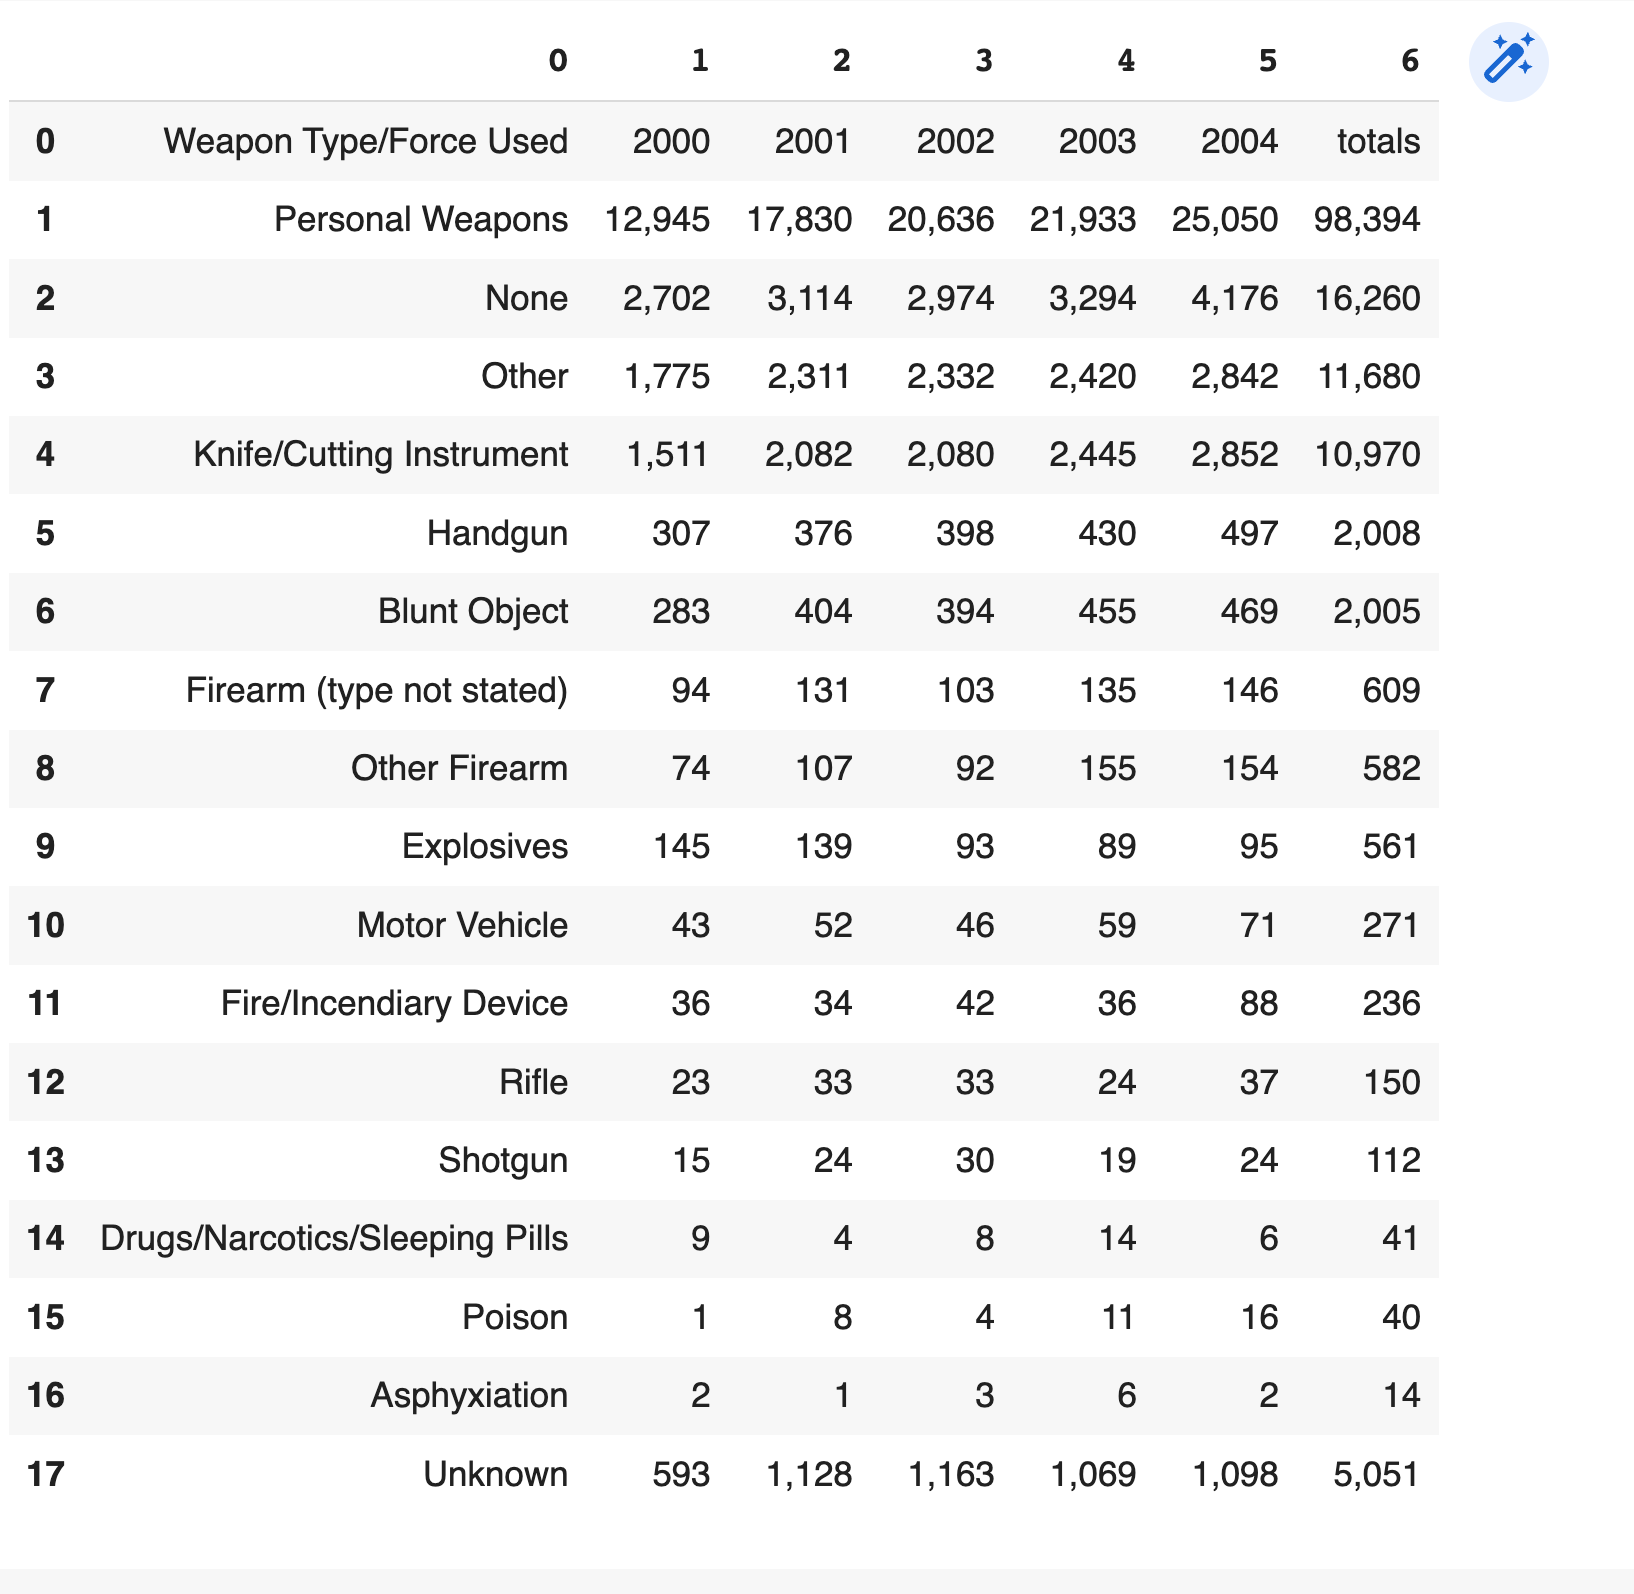

In [ ]:
## Figure out pattern to find all values using regex.101
## regex to find pattern:


In [ ]:
## run regex to find all occurences


In [ ]:
## turn into df


In [ ]:
## target columns


In [ ]:
## designate column headers
## Assign correct headers to columns


In [ ]:
## Recreate the df but from row 1 onward
## name the column headers


In [ ]:
## turn into new dataframe


In [ ]:
## find telephone numbers


In [ ]:
## run pattern on text
